# Evaluación 2 — Reconstrucción con red neuronal y capa de Fourier
**Programación Científica 2026-1 · Universidad Nacional de Colombia**

**Estudiante:** Juan Camilo Castaño Chavarriaga

**Cédula:** 1034991170

---

## Pregunta guía
> ¿Conviene inicializar la primera capa de la red en la **base de Fourier** en lugar de una **base aleatoria** para reconstruir señales de un medio dispersivo?

Aquí crearemos una red $\hat x = W_2\,\tanh(W_1 x)$ con $x\in\mathbb{R}^{256}$, $K=15$ frecuencias, y la entrenaremos sobre los **tres regímenes** del medio ($\mu\in\{0,5,15\}$) con las **dos inicializaciones de $W_1$**, compararemos sus resultados, analizaremos la utilidad de las distintas inicializaciones y además llevaremos a cabo un experimento adicional nacido de querer entender la interacción de una red neuronal y los conceptos relacionados a la transformada de Fourier discreta.

## 0. Imports y estilo del proyecto

Importación de librerías, establecimiento de semilla global y definición de estilo único para las gráficas.

In [1]:
# Librerías: NumPy (cálculo en CPU), Matplotlib (figuras) y JAX (la red, con
# autodiferenciación y compilación JIT).
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit, value_and_grad, random

# JAX usa float32 por defecto; lo subimos a float64 para poder comprobar con precisión
# de máquina identidades como "la capa Fourier es la DFT" o Parseval.
jax.config.update("jax_enable_x64", True)

SEMILLA = 1170          # semilla global; coincide con el ID del enunciado

# Estilo común a todas las figuras: fuente tipo LaTeX (Computer Modern), ticks hacia
# adentro, rejilla gris punteada y marco superior/derecho oculto.
plt.rcParams.update({
    "text.usetex":         True,
    "font.family":         "serif",
    "font.serif":          ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    "font.size":           16,
    "axes.labelsize":      16,
    "axes.titlesize":      18,
    "xtick.labelsize":     14,
    "ytick.labelsize":     14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "axes.grid":           True,
    "grid.color":          "gray",
    "grid.linewidth":      0.3,
    "grid.alpha":          0.3,
    "grid.linestyle":      "--",
    "figure.dpi":          120,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "savefig.dpi":         300,
})

# Un color por régimen (azul, naranja, rojo) más su nombre para títulos y leyendas,
# y un gris para la inicialización aleatoria (la de comparación).
COLOR_REG    = {0: "#1b6ca8", 1: "#e08b00", 2: "#b8002b"}
NOMBRE_REG   = {0: r"Régimen 0 — sin dispersión ($\mu=0$)",
                1: r"Régimen 1 — intermedia ($\mu=5$)",
                2: r"Régimen 2 — fuerte ($\mu=15$)"}
COLOR_RANDOM = "0.55"

print("JAX:", jax.__version__, "| backend:", jax.default_backend())


JAX: 0.10.2 | backend: cpu


# Parte I — Los datos

## 1.1 Carga e inspección
Cada señal tiene 256 muestras en $t\in[0,1)$ s. Hay 8 señales por régimen (24 en total).

Inspección del archivo `datos_1170.npz`, carga y extracción de los tres arrays (`senales`, `regimenes`, `tiempo`), cálculo de parámetros de muestreo (paso temporal, frecuencia de muestreo y frecuencia de Nyquist) e impresión de resumen para confirmar las dimensiones.

### Carga y extracción de la información


In [2]:
# Cargamos el contenedor .npz (varios arrays con nombre dentro de un solo archivo)
datos = np.load("../SolucionReferencia_0000/datos_0000.npz")

senales   = datos["X"].astype(np.float64)   # (24, 256): 24 señales, cada una de 256 muestras
regimenes = datos["y"].astype(np.int64)     # (24,)   : régimen (0, 1 o 2) de cada señal
tiempo    = datos["t"].astype(np.float64)   # (256,)  : instantes de muestreo, compartidos

# Parámetros de muestreo (derivados del eje de tiempo)
n_muestras     = senales.shape[1]               # 256 muestras por señal
paso_temporal  = float(tiempo[1] - tiempo[0])   # Δt entre muestras [s]
frec_muestreo  = 1.0 / paso_temporal            # fs = 1/Δt [Hz]

# Resumen de dimensiones y muestreo
print(f"senales: {senales.shape}  ·  regimenes: {regimenes.shape}  ·  tiempo: {tiempo.shape}")
print(f"Δt = {paso_temporal:.5f} s  ->  fs = {frec_muestreo:.1f} Hz   "
      f"(Nyquist = {frec_muestreo/2:.1f} Hz)")
for r in (0, 1, 2):
    print(f"  régimen {r}: {(regimenes == r).sum()} señales")

senales: (24, 256)  ·  regimenes: (24,)  ·  tiempo: (256,)
Δt = 0.00391 s  ->  fs = 256.0 Hz   (Nyquist = 128.0 Hz)
  régimen 0: 8 señales
  régimen 1: 8 señales
  régimen 2: 8 señales


### Estructura interna del archivo `.npz`

Visualización de los contenidos del archivo, donde se encuentran almacenadas las señales a analizar.

In [3]:
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("styler.render.max_columns", 8)   # resume las 256 columnas con "…"

# Tabla de las señales: cada fila es una señal, con su etiqueta de régimen y sus 256 muestras.
columnas_tiempo = [f"t={ti:.3f}" for ti in tiempo]     # una columna por instante de tiempo
tabla_datos = pd.DataFrame(senales, columns=columnas_tiempo)
tabla_datos.insert(0, "régimen", regimenes)            # el régimen como primera columna
tabla_datos.index.name = "señal #"

def _color_regimen(valor):
    # pinta la celda del régimen con su color de la paleta
    return f"background-color: {COLOR_REG[valor]}; color: white; font-weight: bold"

tabla_estilizada = (tabla_datos.style
    .map(_color_regimen, subset=["régimen"])
    .format("{:.3f}", subset=columnas_tiempo))
display(tabla_estilizada)


,régimen,t=0.000,t=0.004,t=0.008,t=0.012,t=0.016,t=0.020,t=0.023,...
señal #,,,,,,,,,
0,2,0.176,0.418,0.623,0.623,0.584,0.361,0.061,...
1,2,2.010,2.022,1.639,0.979,0.151,-0.702,-1.460,...
2,0,-0.496,-0.589,-0.671,-0.729,-0.758,-0.843,-0.802,...
3,0,-1.553,-1.580,-1.653,-1.621,-1.637,-1.609,-1.572,...
4,0,-0.109,-0.003,0.093,0.230,0.319,0.394,0.493,...
5,0,-0.018,0.267,0.541,0.790,1.024,1.293,1.447,...
6,1,1.563,1.546,1.465,1.226,0.979,0.586,0.182,...
7,1,0.001,0.040,0.051,0.086,0.183,0.200,0.261,...
8,2,-0.692,-0.196,0.308,0.730,1.109,1.247,1.200,...


## 1.2 Visualización de señales por régimen

Para entender mejor los datos con los que estamos trabajando, se muestra la primera señal de cada régimen y se establece el código de colores que caracterizará nuestro análisis: 
Azul para **régimen 0**, sin dispersión; naranja para **régimen 1**, con dispersión intermedia; rojo para **régimen 2**, con dispesión fuerte. 

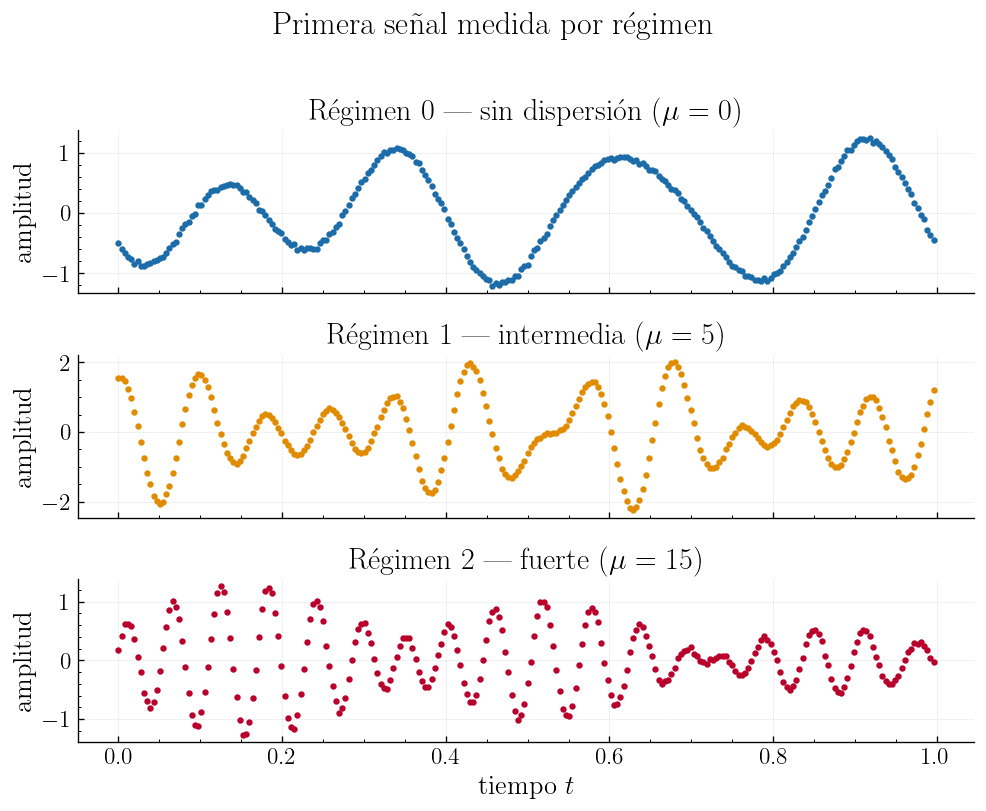

In [4]:
# Un panel por régimen: mostramos la PRIMERA señal de cada uno como muestras discretas
fig, axes = plt.subplots(3, 1, figsize=(8.5, 6.8), sharex=True)

for ax, reg in zip(axes, (0, 1, 2)):
    indice = np.where(regimenes == reg)[0][0]        # índice de la 1ª señal de este régimen
    ax.plot(tiempo, senales[indice], marker="o", linestyle="none", markersize=2.8,
            color=COLOR_REG[reg])                     # solo puntos = señal discreta
    ax.set_ylabel("amplitud")
    ax.set_title(NOMBRE_REG[reg])

axes[-1].set_xlabel(r"tiempo  $t$")

fig.suptitle("Primera señal medida por régimen", y=1.0)
fig.tight_layout()
plt.show()

## 1.3 Visualización del espectro de las señales
Pues haremos un análisis con Fourier, vale la pena explorar el espectro que caracteriza a cada régimen. Así, visualizamos $|\mathrm{FFT}(x)|$ de las 24 señales. Para ello se calcula la transformada de Fourier de cada señal para obtener el espectro de amplitud promedio, que es mostrado por la línea oscura, mientras que la banda que lo rodea representa la desviación estándar de cada conjunto de señales.

La línea vertical marca la **frecuencia máxima $K=15$ Hz** que la capa Fourier podrá representar.


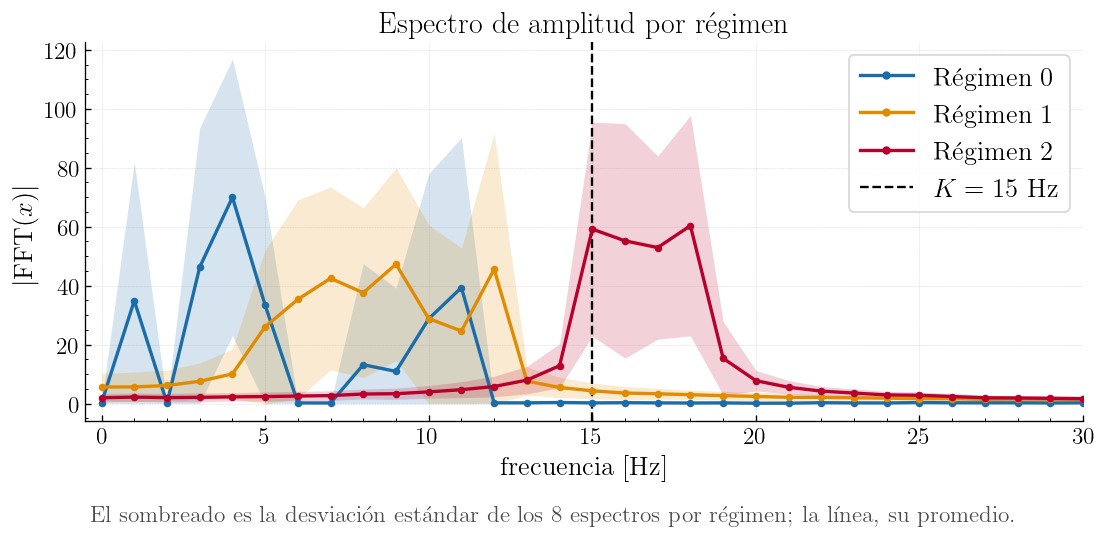

In [5]:
K = 15                                   # número de frecuencias que tendrá la capa Fourier
frecuencias = np.fft.rfftfreq(n_muestras, d=paso_temporal)   # eje de frecuencias de la FFT real [Hz]
banda_visible = frecuencias <= 30        # solo mostramos hasta 30 Hz (ahí está la acción)
f = frecuencias[banda_visible]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for reg in (0, 1, 2):
    espectros_reg = np.abs(np.fft.rfft(senales[regimenes == reg], axis=1))[:, banda_visible]  # (8, n_freq)
    media = espectros_reg.mean(axis=0)   # espectro promedio del régimen
    desv  = espectros_reg.std(axis=0)    # dispersión señal a señal (desviación estándar)

    # banda sombreada = media ± desviación (variabilidad entre las 8 señales)
    ax.fill_between(f, np.clip(media - desv, 0, None), media + desv,
                    color=COLOR_REG[reg], alpha=0.18, lw=0, zorder=1)
    # espectro PROMEDIO resaltado (línea oscura + marcador por bin de la DFT)
    ax.plot(f, media, color=COLOR_REG[reg], lw=2.0, marker="o", markersize=3.5, zorder=3)

ax.axvline(K, color="k", ls="--", lw=1.4)         # corte de la capa Fourier (K = 15 Hz)
ax.set_xlim(-0.5, 30)
ax.set_xlabel("frecuencia  [Hz]")
ax.set_ylabel(r"$|\mathrm{FFT}(x)|$")
ax.set_title("Espectro de amplitud por régimen")

# Leyenda: color = régimen (la línea con marcadores es el promedio; el sombreado, la desviación)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=COLOR_REG[r], lw=2.0, marker="o", ms=4,
                  label=f"Régimen {r}") for r in (0, 1, 2)]
handles.append(Line2D([0], [0], color="k", ls="--", lw=1.4, label=r"$K=15$ Hz"))
ax.legend(handles=handles, loc="upper right")

# Pie de página (grande y pegado a la gráfica): qué representa el sombreado
fig.tight_layout(rect=[0, 0.045, 1, 1])
fig.text(0.5, 0.015,
         "El sombreado es la desviación estándar de los 8 espectros por régimen; la línea, su promedio.",
         ha="center", va="bottom", fontsize=14, style="italic", color="0.3")
plt.show()



**Observación:** De esta visualización es interesante concluir que gran parte de los modos de las señales para el **régimen 2** sobrepasan la frecuencia máxima, pues caen entre **15 y 19 Hz**, lo que da pistas de las futuras dificultades que podrá tener la arquitectura escogida para reconstruir las señales de dicho régimen.

# Parte II — La capa Fourier

## 2.1 Construcción de $W_1$
Para cada $k=1,\dots,15$ tomamos dos filas, una para coseno y otra para seno, escaladas por $2/N$, el cual es un factor de la DFT en amplitudes:

$$\bigl(W_1^{\text{Fourier}}\bigr)_{2k-2,\,n}=\tfrac{2}{N}\cos(2\pi k\,t_n),\qquad
\bigl(W_1^{\text{Fourier}}\bigr)_{2k-1,\,n}=\tfrac{2}{N}\sin(2\pi k\,t_n).$$

Sin este factor $W_1 x$ alcanzaría valores $\sim N/2$ y la $\tanh$ se saturaría desde la iteración 0 (gradiente nulo).

Aquí definimos la función `matriz_fourier` que arma esa matriz y construimos `W1_fourier`.

In [6]:
def matriz_fourier(tiempo, K, escala):
    """Matriz de la capa Fourier: 2K filas (un coseno y un seno por frecuencia k=1..K)
    por n_muestras columnas. La escala 2/N reproduce las amplitudes de la DFT."""
    k = np.arange(1, K + 1)[:, None]                   # frecuencias k = 1..K, en columna
    cosenos = escala * np.cos(2 * np.pi * k * tiempo)
    senos   = escala * np.sin(2 * np.pi * k * tiempo)
    W1 = np.empty((2 * K, tiempo.size))
    W1[0::2] = cosenos    # filas pares: cosenos
    W1[1::2] = senos      # filas impares: senos
    return W1

# W1 con la escala 2/N (la de las amplitudes de la DFT).
W1_fourier = matriz_fourier(tiempo, K, escala=2.0 / n_muestras)
print("W1_fourier shape:", W1_fourier.shape)


W1_fourier shape: (30, 256)


## 2.2 Verificación: $W_1 x$ ES la DFT
Cada par de salidas de la capa Fourier debe coincidir, salvo el signo, con la parte real y la parte imaginaria del coeficiente DFT correspondiente:

$$\bigl(W_1 x\bigr)_{2k-2}=\tfrac{2}{N}\,\mathrm{Re}\,X_k,\qquad
\bigl(W_1 x\bigr)_{2k-1}=-\tfrac{2}{N}\,\mathrm{Im}\,X_k.$$

**En esta celda** tomamos una señal de ejemplo, le aplicamos la capa (`W1_fourier @ x`) y la DFT de NumPy, y comprobamos que coinciden hasta la precisión de máquina.

**Sobre `np.fft`.** `np.fft.rfft` recibe **una señal real** (un vector de $N$ muestras) y devuelve $N/2+1$ **coeficientes complejos**: cada uno da la amplitud y la fase de una frecuencia. Se puede aplicar a **una señal** o a **varias a la vez** (con `axis=1`); aquí lo usamos sobre una señal de ejemplo, y en la Parte I sobre las 24. La capa $W_1$ reproduce, salvo el factor $2/N$, la parte real y la imaginaria de esos coeficientes para $k=1,\dots,15$.


In [7]:
# Tomamos una señal de ejemplo (la 1ª del régimen 1)
indice_ejemplo = np.where(regimenes == 1)[0][0]
senal_ejemplo  = senales[indice_ejemplo]

salida_capa  = W1_fourier @ senal_ejemplo     # (2K,): lo que produce la capa Fourier
espectro_dft = np.fft.rfft(senal_ejemplo)     # DFT de NumPy (complejo) para comparar

# La capa (escalada 2/N) debe reproducir la parte real y la imaginaria (con signo) de la DFT
real_dft  =  (2.0 / n_muestras) * espectro_dft[1:K+1].real
imag_dft  = -(2.0 / n_muestras) * espectro_dft[1:K+1].imag   # signo: e^{-i2πkt} = cos - i·sin
real_capa = salida_capa[0::2]                  # filas coseno -> parte real
imag_capa = salida_capa[1::2]                  # filas seno   -> parte imaginaria

# Máximo error entre la capa y la DFT (debe ser ~1e-15, precisión de máquina)
err_real = np.max(np.abs(real_capa - real_dft))
err_imag = np.max(np.abs(imag_capa - imag_dft))

print(f"max |Re(W1 x) - (2/N)*Re(DFT)|  = {err_real:.3e}")
print(f"max |Im(W1 x) - (-2/N)*Im(DFT)| = {err_imag:.3e}")
print("-> Coinciden (precisión de máquina): la capa Fourier, en su inicialización,")
print("   ES la DFT en amplitudes.")

max |Re(W1 x) - (2/N)*Re(DFT)|  = 9.975e-16
max |Im(W1 x) - (-2/N)*Im(DFT)| = 1.110e-15
-> Coinciden (precisión de máquina): la capa Fourier, en su inicialización,
   ES la DFT en amplitudes.


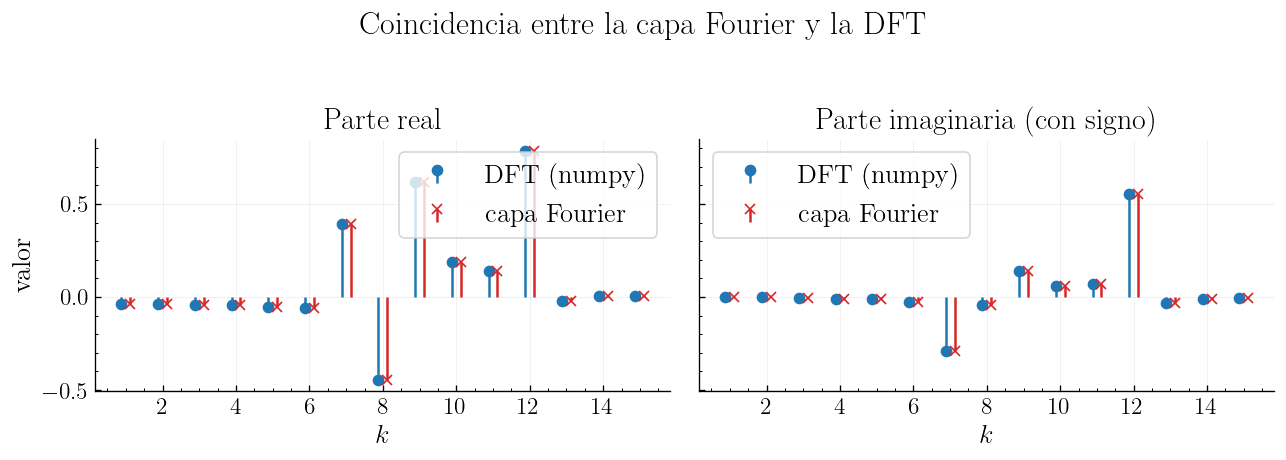

In [8]:
# Comparamos coeficiente a coeficiente la salida de la capa (cruces) con la DFT de numpy
# (círculos). Los stems se desplazan ±0.12 en k para que no se pisen y se vea que coinciden.
k_indices = np.arange(1, K + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

for ax, dft, capa, titulo in [(axes[0], real_dft, real_capa, "Parte real"),
                              (axes[1], imag_dft, imag_capa, "Parte imaginaria (con signo)")]:
    ax.stem(k_indices - 0.12, dft,  linefmt="C0-", markerfmt="C0o", basefmt=" ", label="DFT (numpy)")
    ax.stem(k_indices + 0.12, capa, linefmt="C3-", markerfmt="C3x", basefmt=" ", label="capa Fourier")
    ax.set_title(titulo)
    ax.set_xlabel(r"$k$")
    ax.legend()
axes[0].set_ylabel("valor")

fig.suptitle("Coincidencia entre la capa Fourier y la DFT", y=1.02)
fig.tight_layout()
plt.show()


## 2.3 Energía media del dataset
Reportamos la **energía media** de las señales, $\langle x^2\rangle=$ `(X**2).mean()`. Es la **escala** de la pérdida: como $\hat x(0)\approx 0$, la pérdida inicial vale $\mathcal{L}(0)\approx\langle x^2\rangle$. Además convierte la pérdida (MSE) en **error relativo**:
$$\text{error relativo}=\frac{\lVert\hat x-x\rVert}{\lVert x\rVert}=\sqrt{\frac{\mathcal{L}}{\langle x^2\rangle}}.$$
Por eso la necesitamos: nos deja leer la pérdida en términos relativos y fijar el umbral "error relativo $=0.1$" de la Parte III.

### Respuestas a las preguntas de la rúbrica
- **¿Cuáles son las entradas y salidas de `np.fft`?** Entrada: una señal **real** (vector de $N=256$ muestras). Salida (`rfft`): $N/2+1=129$ **coeficientes complejos** $X_k$; cada uno codifica la **amplitud y la fase** de la frecuencia $k$.
- **¿Se hace a una señal o a varias?** A cualquiera: a **una** señal (como en 2.2) o a **varias a la vez** pasando `axis=1` (como en 1.3, sobre las 24 señales).
- **¿Para qué reportar la energía media del dataset?** Es la **escala** de la pérdida ($\mathcal{L}(0)\approx\langle x^2\rangle$) y permite convertir el MSE en **error relativo** $\lVert\hat x-x\rVert/\lVert x\rVert=\sqrt{\mathcal{L}/\langle x^2\rangle}$; así fijamos el umbral "error relativo $=0.1$" de la Parte III.


In [9]:
# Energía media del dataset completo (escala de la pérdida)
energia_media = (senales ** 2).mean()
print(f"Energía media del dataset  (X**2).mean() = {energia_media:.3f}")

# Energía media por régimen (para convertir pérdida -> error relativo en la Parte III)
energia_reg = {r: float((senales[regimenes == r] ** 2).mean()) for r in (0, 1, 2)}
for r in (0, 1, 2):
    print(f"  régimen {r}: energía media = {energia_reg[r]:.3f}")


Energía media del dataset  (X**2).mean() = 0.678
  régimen 0: energía media = 0.824
  régimen 1: energía media = 0.617
  régimen 2: energía media = 0.591


# Parte III — La red y el entrenamiento

Construiremos una arquitectura de red neuronal dada por:

$$\hat x = W_2\,\tanh(W_1 x),\qquad W_1\in\mathbb{R}^{2K\times N},\ W_2\in\mathbb{R}^{N\times 2K}.$$

Con una función de pérdida MSE por muestra:

$$\mathcal{L}(W_1,W_2)=\frac1N\|\hat x - x\|^2.$$

**Consideraciones de la arquitectura.**

- *Inicialización de $W_1$:* Fourier (escalada $2/N$) **vs.** aleatoria $\mathcal{N}(0,\sigma^2)$ con $\sigma=\sqrt2/N$ para que sus filas tengan la **misma norma** que las de Fourier.
- *Inicialización de $W_2$:* la misma para ambos modelos, con $\sigma_{W_2}=0.01$. Aquí, $\hat x(0)\approx 0$ y la pérdida inicial es $\approx\mathrm{var}(x)$, con valores idénticos para los dos.
- *Optimizador:* **SGD con momento** ($\beta=0.9$), $\eta=0.05$ — el momento es estándar y necesario para que el SGD converja en 3000 iteraciones con este $\eta$ tan pequeño.
- *Reducción de varianza:* repetimos con **3 semillas** distintas (afectan a $W_2$ y a $W_1^{\text{rand}}$). Reportamos media y dispersión.

Definición de la propagación de la red (`forward`), la pérdida (`loss`), el gradiente compilado `grad_loss = jit(grad(loss))` (backpropagation), un paso de SGD con momento (`paso_sgd`), las dos inicializaciones (`init_fourier`, `init_random`) y el bucle `entrenar`. Los parámetros se guardan como un **pytree** (diccionario `{W1, W2}`) y se actualizan con `jax.tree_util.tree_map`, sin bucles por peso.

In [10]:
# La red es x_hat = W2 · tanh(W1 · x). Guardamos sus pesos en un diccionario {W1, W2}
# (un "pytree"), que JAX sabe recorrer para derivar y actualizar sin escribir bucles por peso.

def forward(params, x):
    """Paso hacia adelante: reconstruye las señales como W2 · tanh(W1 · x)."""
    oculta = jnp.tanh(x @ params["W1"].T)   # capa oculta (n, 2K)
    return oculta @ params["W2"].T          # reconstrucción (n, N)

def loss(params, x):
    """Error cuadrático medio entre la reconstrucción y la señal original."""
    return jnp.mean((forward(params, x) - x) ** 2)

# grad_loss deriva la pérdida por backpropagation; jit lo compila una vez para que las
# 3000 iteraciones vuelen. loss_jit es la misma pérdida compilada, para ir registrándola.
grad_loss = jit(grad(loss))
loss_jit  = jit(loss)

SIGMA_W1_RANDOM = np.sqrt(2.0) / n_muestras   # da a la W1 aleatoria la misma norma de fila que Fourier
SIGMA_W2        = 0.01                          # W2 pequeña: x_hat(0) ~ 0, así L(0) ~ energía media

@jit
def paso_sgd(params, velocidad, x, lr=0.05, beta=0.9):
    """Un paso de descenso por gradiente con momento (beta=0.9)."""
    grads = grad_loss(params, x)
    velocidad = jax.tree_util.tree_map(lambda v, g: beta * v + g, velocidad, grads)  # momento
    params    = jax.tree_util.tree_map(lambda p, v: p - lr * v, params, velocidad)   # p <- p - lr·v
    return params, velocidad

def init_fourier(tiempo, K, clave_w2):
    """Inicialización Fourier: W1 es la matriz de Fourier; W2 es ruido pequeño."""
    W1 = jnp.asarray(matriz_fourier(np.asarray(tiempo), K, escala=2.0 / tiempo.size))
    W2 = random.normal(clave_w2, (tiempo.size, 2 * K)) * SIGMA_W2
    return {"W1": W1, "W2": W2}

def init_random(n_muestras, K, clave_w1, clave_w2):
    """Inicialización aleatoria: W1 es ruido con la misma norma de fila que Fourier; W2, el mismo ruido."""
    W1 = random.normal(clave_w1, (2 * K, n_muestras)) * SIGMA_W1_RANDOM
    W2 = random.normal(clave_w2, (n_muestras, 2 * K)) * SIGMA_W2
    return {"W1": W1, "W2": W2}

def entrenar(params, x, n_iter=3000, lr=0.05):
    """Entrena la red y devuelve los pesos finales y la curva de pérdida por iteración."""
    velocidad = jax.tree_util.tree_map(jnp.zeros_like, params)   # momento inicial en cero
    historial = np.empty(n_iter)
    for i in range(n_iter):
        params, velocidad = paso_sgd(params, velocidad, x, lr=lr)
        historial[i] = float(loss_jit(params, x))
    return params, historial


## 3.1 Entrenamiento: 3 regímenes × 2 inicializaciones × 3 semillas
3000 iteraciones con $\eta=0.05$. Guardamos toda la historia para analizar la dinámica.

**En esta celda** corremos el experimento completo: para cada semilla y cada régimen entrenamos dos redes (init Fourier y aleatoria, con el mismo $W_2$), guardamos las curvas de pérdida en `resultados` y los pesos finales, e imprimimos un resumen.

In [11]:
# Experimento central: por cada régimen entrenamos dos redes iguales salvo el punto de
# partida de W1 (Fourier vs aleatorio) y repetimos con 3 semillas. Guardamos toda la curva
# de pérdida en 'resultados', y los pesos finales de la última semilla para reconstruir luego.
N_ITER, LR, N_SEEDS = 3000, 0.05, 3

resultados = {r: {"fourier": {"loss": np.zeros((N_SEEDS, N_ITER))},
                  "random":  {"loss": np.zeros((N_SEEDS, N_ITER))}}
              for r in (0, 1, 2)}

for s in range(N_SEEDS):
    clave = random.PRNGKey(SEMILLA + s)
    clave_w1_rand, clave_w2 = random.split(clave)   # W2 se comparte entre las dos inicializaciones
    for reg in (0, 1, 2):
        senales_reg = jnp.asarray(senales[regimenes == reg])   # las 8 señales del régimen
        params_fourier = init_fourier(tiempo, K, clave_w2)
        params_random  = init_random(n_muestras, K, clave_w1_rand, clave_w2)

        params_fourier_final, hist_fourier = entrenar(params_fourier, senales_reg, N_ITER, LR)
        params_random_final,  hist_random  = entrenar(params_random,  senales_reg, N_ITER, LR)
        resultados[reg]["fourier"]["loss"][s] = hist_fourier
        resultados[reg]["random"]["loss"][s]  = hist_random

        if s == N_SEEDS - 1:   # nos quedamos con los pesos de la última semilla para las reconstrucciones
            resultados[reg]["fourier"]["params_last"] = params_fourier_final
            resultados[reg]["random"]["params_last"]  = params_random_final

# Pérdida inicial (L0, igual para ambas por diseño) y final, promediadas sobre las semillas.
print("Resumen (media sobre semillas):")
print(f"{'reg':>3} {'L0':>8} {'L_final_F':>10} {'L_final_R':>10}")
for reg in (0, 1, 2):
    L0        = resultados[reg]["fourier"]["loss"][:, 0].mean()
    L_final_f = resultados[reg]["fourier"]["loss"][:, -1].mean()
    L_final_r = resultados[reg]["random"]["loss"][:, -1].mean()
    print(f"{reg:>3} {L0:>8.4f} {L_final_f:>10.2e} {L_final_r:>10.2e}")


Resumen (media sobre semillas):
reg       L0  L_final_F  L_final_R
  0   0.8244   2.44e-11   4.32e-12
  1   0.6171   1.61e-13   3.52e-13
  2   0.5914   3.19e-09   2.21e-08


## 3.2 Evolución de la pérdida
Visualización en **escala logarítmica** de la evolución de la función de pérdida. Aquí, la línea gruesa representa el promedio sobre las 3 semillas y las líneas finas representan las 3 corridas individuales.


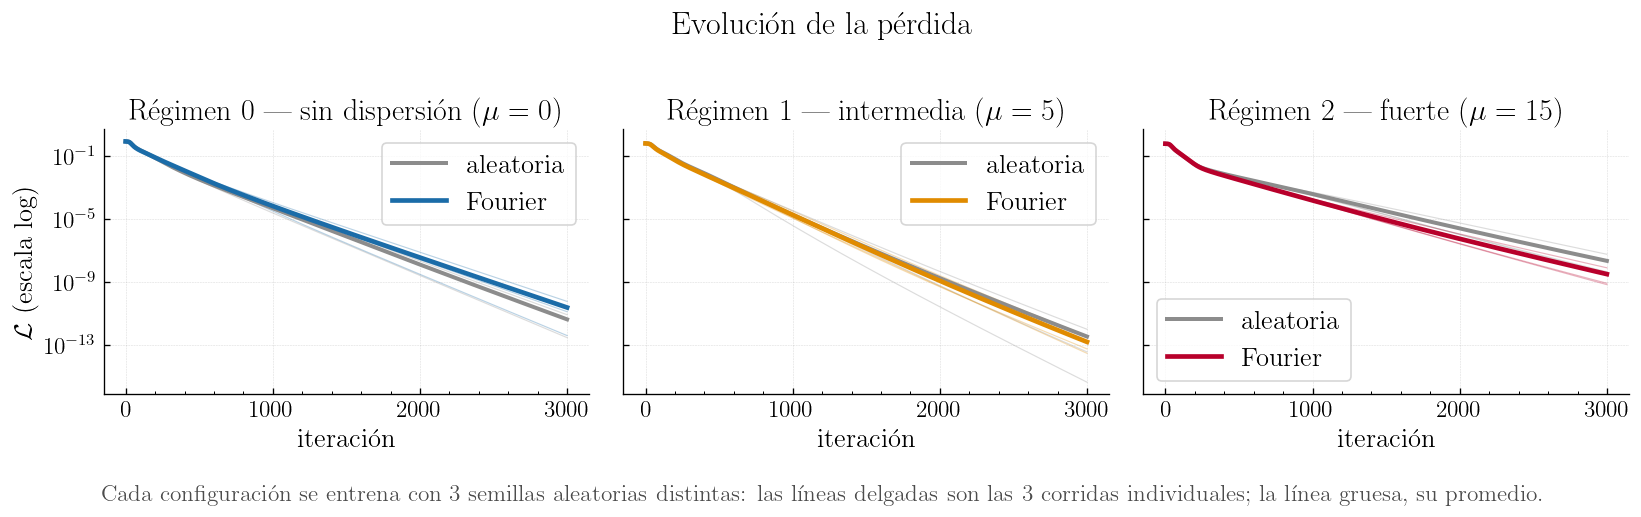

In [ ]:
# Curvas de pérdida en escala log, un panel por régimen, con las dos inicializaciones
# superpuestas. Línea gruesa: promedio sobre semillas; líneas finas: cada semilla.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
iteraciones = np.arange(N_ITER)
for col, reg in enumerate((0, 1, 2)):
    perdidas_fourier = resultados[reg]["fourier"]["loss"]
    perdidas_random  = resultados[reg]["random"]["loss"]
    ax = axes[col]
    for s in range(N_SEEDS):   # las 3 semillas, tenues
        ax.loglog(iteraciones, perdidas_random[s],  color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.loglog(iteraciones, perdidas_fourier[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    ax.loglog(iteraciones, perdidas_random.mean(0),  color=COLOR_RANDOM, lw=2.4, label="aleatoria")
    ax.loglog(iteraciones, perdidas_fourier.mean(0), color=COLOR_REG[reg], lw=2.8, label="Fourier")
    ax.set_title(NOMBRE_REG[reg])
    ax.set_xlabel("iteración")
    ax.legend()

axes[0].set_ylabel(r"$\mathcal{L}$  (escala log)")
fig.suptitle(r"Evolución de la pérdida", y=1.0)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.02,
         "Cada configuración se entrena con 3 semillas aleatorias distintas: las líneas delgadas son "
         "las 3 corridas individuales; la línea gruesa, su promedio.",
         ha="center", va="bottom", fontsize=14, style="italic", color="0.3")
plt.show()


## 3.3 ¿Cuánto más rápido aprende la inicialización Fourier?
**¿La pérdida es el error relativo? No.** La pérdida es el MSE $\mathcal{L}=\tfrac1N\lVert\hat x-x\rVert^2$; el error relativo es $\lVert\hat x-x\rVert/\lVert x\rVert=\sqrt{\mathcal{L}/\langle x^2\rangle}$. Por eso "error relativo $=0.1$" equivale a $\mathcal{L}<0.01\,\langle x^2\rangle$.

Medimos dos cosas: (1) **cuántas iteraciones** necesita cada inicialización para bajar el error relativo por debajo de **0.1**, y (2) el cociente $L_{\text{rand}}/L_{\text{four}}$ a iteraciones fijas ($>1\Rightarrow$ Fourier va por delante).


In [13]:
# Dos medidas de "cuánto más rápido aprende Fourier".

# (1) Iteraciones hasta que el error relativo baja de 0.1. Como err_rel = sqrt(L / <x^2>),
#     equivale a que la pérdida caiga por debajo de 0.01·<x^2> (energía media del régimen).
def primer_iter_bajo(curva, umbral):
    idx = np.where(curva < umbral)[0]
    return int(idx[0]) if len(idx) else None

print("Iteraciones hasta error relativo < 0.1:")
print(f"{'reg':>3} {'Fourier':>9} {'aleatoria':>10}")
for reg in (0, 1, 2):
    umbral_L = 0.01 * energia_reg[reg]
    it_f = primer_iter_bajo(resultados[reg]["fourier"]["loss"].mean(0), umbral_L)
    it_r = primer_iter_bajo(resultados[reg]["random"]["loss"].mean(0),  umbral_L)
    print(f"{reg:>3} {str(it_f):>9} {str(it_r):>10}")
print()

# (2) Cociente de las pérdidas medias a iteraciones fijas. Un valor > 1 quiere decir que
#     Fourier tiene menor pérdida, es decir, va por delante.
print(f"{'reg':>3} {'iter':>6} {'L_fourier':>11} {'L_random':>11} {'Lrand/Lfour':>14}")
for reg in (0, 1, 2):
    media_fourier = resultados[reg]["fourier"]["loss"].mean(0)
    media_random  = resultados[reg]["random"]["loss"].mean(0)
    for it in (50, 100, 200, 500, 1500):
        lf, lr = media_fourier[it - 1], media_random[it - 1]
        print(f"{reg:>3} {it:>6} {lf:>11.5f} {lr:>11.5f} {lr/lf:>14.3f}")
    print()


Iteraciones hasta error relativo < 0.1:
reg   Fourier  aleatoria
  0       437        401
  1       406        426
  2       392        437

reg   iter   L_fourier    L_random    Lrand/Lfour
  0     50     0.45886     0.48551          1.058
  0    100     0.21975     0.22732          1.034
  0    200     0.08055     0.07584          0.942
  0    500     0.00457     0.00322          0.705
  0   1500     0.00000     0.00000          0.531

  1     50     0.40780     0.44728          1.097
  1    100     0.18704     0.20550          1.099
  1    200     0.05422     0.06392          1.179
  1    500     0.00247     0.00294          1.189
  1   1500     0.00000     0.00000          1.172

  2     50     0.34754     0.33770          0.972
  2    100     0.14310     0.14011          0.979
  2    200     0.02931     0.02982          1.017
  2    500     0.00304     0.00434          1.426
  2   1500     0.00001     0.00003          3.592



## 3.4 Velocidad de convergencia para el régimen 0
El enunciado pide **prestar especial atención al régimen 0** y a la velocidad con que cada inicialización mejora. Aquí lo aislamos: graficamos el **cociente entre la pérdida de la inicialización aleatoria y la de Fourier** a lo largo del entrenamiento. Cuando el cociente está por encima de 1, la inicialización de Fourier tiene menor pérdida, es decir, va por delante.


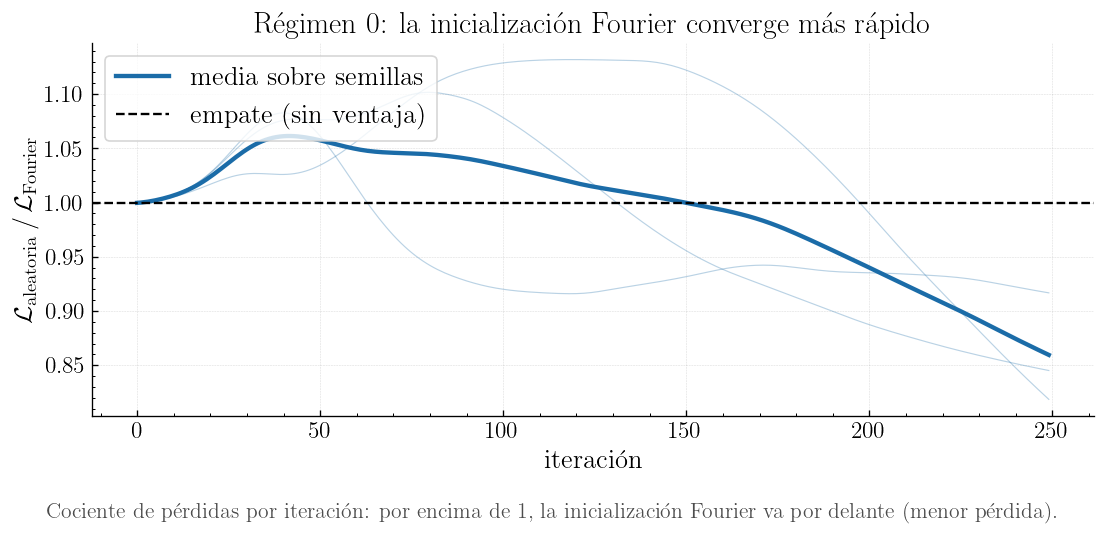

In [14]:
reg = 0
pf = resultados[reg]["fourier"]["loss"]   # (N_SEEDS, N_ITER)
pr = resultados[reg]["random"]["loss"]
iteraciones = np.arange(N_ITER)
n_zoom = 250                               # fase decisiva del entrenamiento

fig, ax = plt.subplots(figsize=(9.5, 4.6))
# las 3 semillas, tenues
for s in range(N_SEEDS):
    ax.plot(iteraciones[:n_zoom], (pr[s] / pf[s])[:n_zoom], color=COLOR_REG[0], lw=0.7, alpha=0.30)
# cociente de las pérdidas medias (línea gruesa)
ventaja = pr.mean(0) / pf.mean(0)
ax.plot(iteraciones[:n_zoom], ventaja[:n_zoom], color=COLOR_REG[0], lw=2.6, label="media sobre semillas")
ax.axhline(1.0, color="k", ls="--", lw=1.4, label="empate (sin ventaja)")

ax.set_xlabel("iteración")
ax.set_ylabel(r"$\mathcal{L}_{\mathrm{aleatoria}} \,/\, \mathcal{L}_{\mathrm{Fourier}}$")
ax.set_title("Régimen 0: la inicialización Fourier converge más rápido")
ax.legend(loc="upper left")

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.02,
         "Cociente de pérdidas por iteración: por encima de 1, la inicialización Fourier va por delante (menor pérdida).",
         ha="center", va="bottom", fontsize=13, style="italic", color="0.3")
plt.show()


## 3.5 Reconstrucción cualitativa

Aquí visualizaremos una señal de cada régimen y su reconstrucción tras 3000 iteraciones.

Definimos una función de reconstrucción, `reconstruir`, la cual consume una señal y la pasa por la red entrenada, y graficamos, por régimen, la señal original con las dos reconstrucciones, Fourier y aleatoria, encima, anotando su error de reconstrucción relativo $\|\hat x-x\|/\|x\|$.

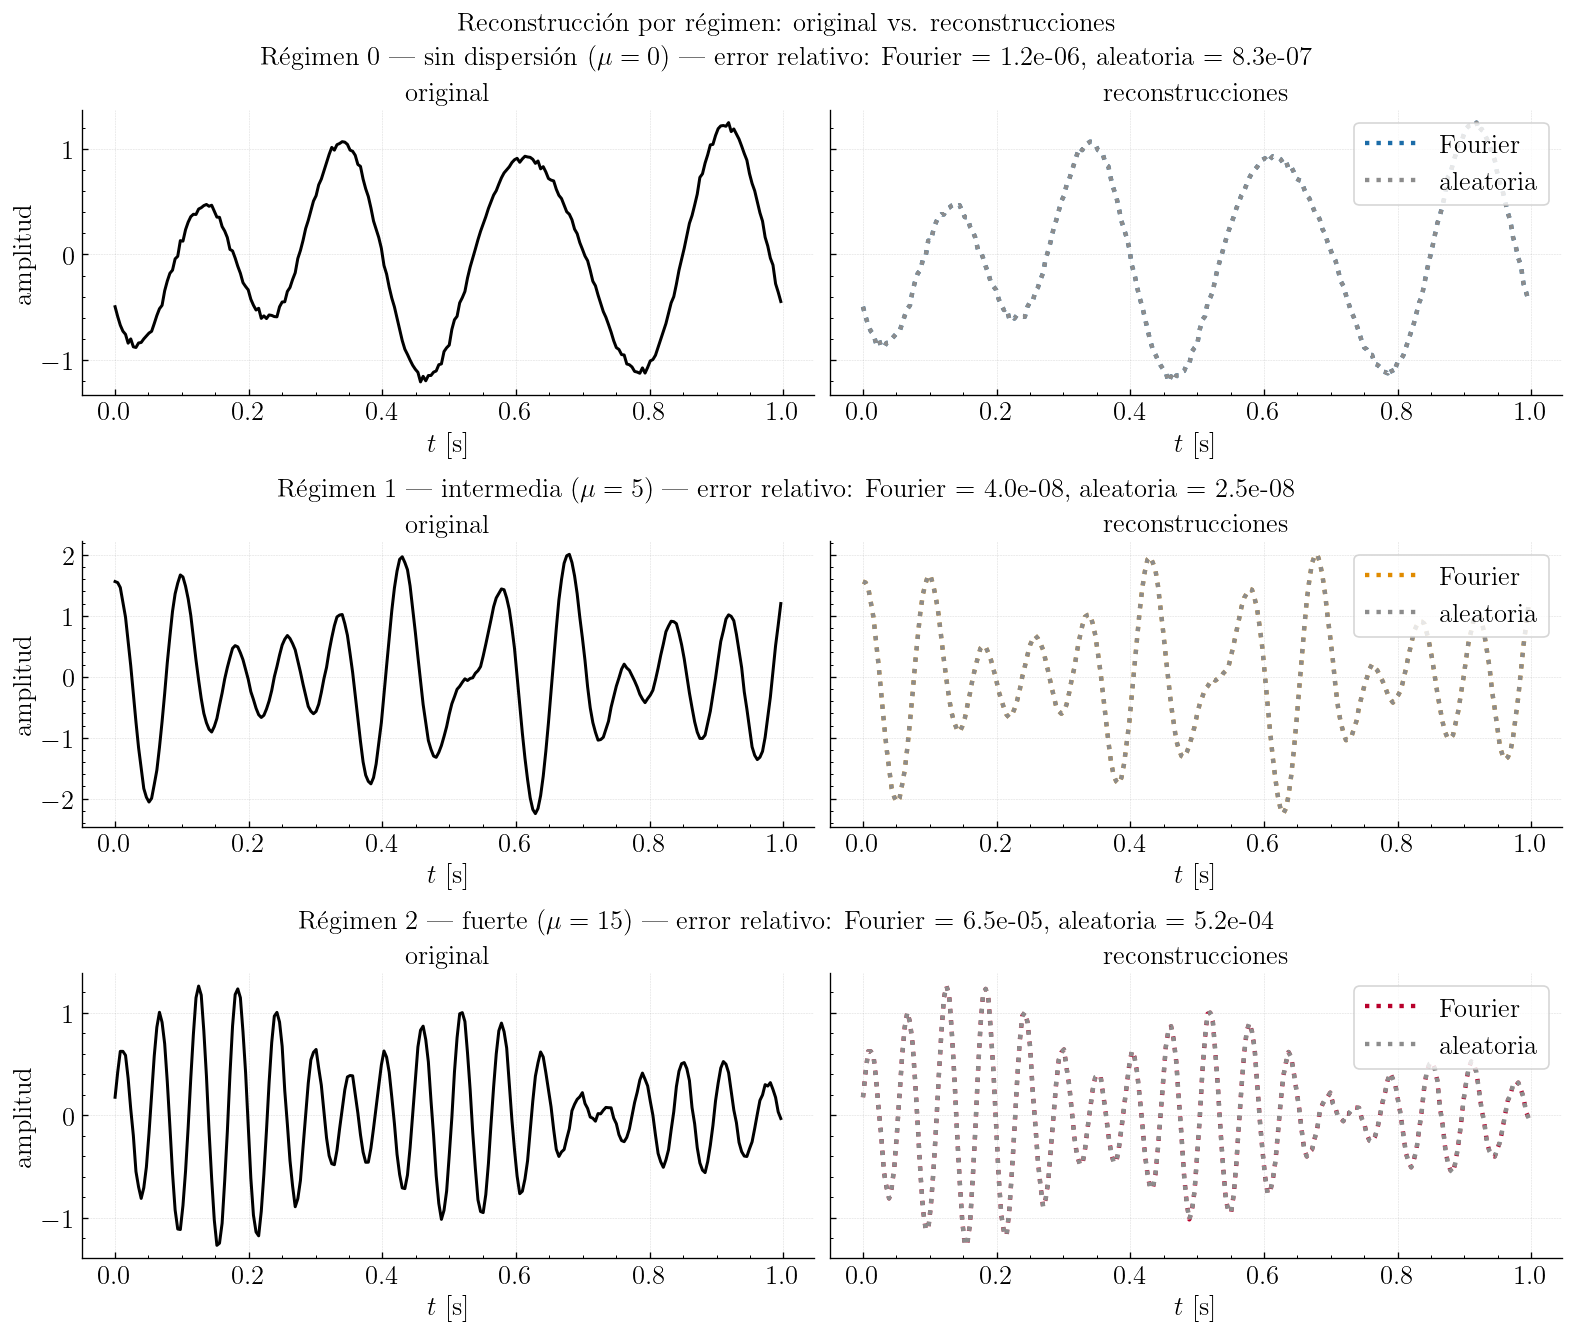

In [15]:
def reconstruir(reg, indice_local):
    """Devuelve (señal original, reconstrucción Fourier, reconstrucción aleatoria)
    para la señal 'indice_local'-ésima del régimen dado, usando los pesos finales."""
    indice_global = np.where(regimenes == reg)[0][indice_local]
    senal = senales[indice_global]
    recon_fourier = np.asarray(forward(resultados[reg]["fourier"]["params_last"], jnp.asarray(senal[None, :])))[0]
    recon_random  = np.asarray(forward(resultados[reg]["random"]["params_last"], jnp.asarray(senal[None, :])))[0]
    return senal, recon_fourier, recon_random

# Todo el texto de esta figura al MISMO tamaño (16 pt)
TAM = 16
with plt.rc_context({"font.size": TAM, "axes.titlesize": TAM, "axes.labelsize": TAM,
                     "xtick.labelsize": TAM, "ytick.labelsize": TAM,
                     "legend.fontsize": TAM, "figure.titlesize": TAM}):
    fig = plt.figure(figsize=(13, 11), layout="constrained")
    subfigs = fig.subfigures(3, 1)
    for sf, reg in zip(subfigs, (0, 1, 2)):
        senal, recon_fourier, recon_random = reconstruir(reg, 0)
        err_fourier = np.linalg.norm(senal - recon_fourier) / np.linalg.norm(senal)
        err_random  = np.linalg.norm(senal - recon_random)  / np.linalg.norm(senal)
        ax = sf.subplots(1, 2, sharey=True)
        # izquierda: la señal ORIGINAL sola
        ax[0].plot(tiempo, senal, "-", color="k", lw=1.8)
        ax[0].set_title("original")
        ax[0].set_ylabel("amplitud")
        ax[0].set_xlabel(r"$t$  [s]")
        # derecha: las RECONSTRUCCIONES solas (punteadas)
        ax[1].plot(tiempo, recon_fourier, ":", color=COLOR_REG[reg], lw=2.6, label="Fourier")
        ax[1].plot(tiempo, recon_random,  ":", color=COLOR_RANDOM,   lw=2.6, label="aleatoria")
        ax[1].set_title("reconstrucciones")
        ax[1].set_xlabel(r"$t$  [s]")
        ax[1].legend(loc="upper right")
        sf.suptitle(fr"{NOMBRE_REG[reg]} — error relativo:  Fourier $=$ {err_fourier:.1e},  aleatoria $=$ {err_random:.1e}")
    fig.suptitle("Reconstrucción por régimen: original vs. reconstrucciones")
    plt.show()


## 3.6 Error de reconstrucción relativo por régimen
Reportamos el **error de reconstrucción relativo** $\lVert\hat x-x\rVert/\lVert x\rVert$ (media $\pm$ desviación sobre las 8 señales de cada régimen, última semilla), para cada inicialización.

**¿Datos de entrenamiento o de validación?** Reconstruimos **las mismas 8 señales con las que se entrenó** cada red, así que este error mide la **capacidad de reconstrucción (ajuste)**, no la generalización. El enunciado plantea un autoencoder de reconstrucción sobre pocas señales por régimen y no pide partición; una señal de validación mediría generalización a señales no vistas. **Diferencia entre parametrizaciones:** ambas reconstruyen bien; los errores son del mismo orden, con Fourier y aleatoria muy parejas al final (la ventaja de Fourier está en la *velocidad* inicial, no en el error final).


In [16]:
# Error de reconstrucción relativo medio sobre las 8 señales de cada régimen, para cada
# inicialización. Confirma que ambas reconstruyen bien y que quedan del mismo orden.
def error_relativo_medio(clave_init):
    filas = []
    for reg in (0, 1, 2):
        senales_reg = senales[regimenes == reg]
        recon = np.asarray(forward(resultados[reg][clave_init]["params_last"], jnp.asarray(senales_reg)))
        err = np.linalg.norm(recon - senales_reg, axis=1) / np.linalg.norm(senales_reg, axis=1)  # uno por señal
        filas.append((reg, err.mean()))
    return filas

print(f"{'reg':>3} {'err_rel_fourier':>18} {'err_rel_aleatoria':>20}")
for (reg, mf), (_, mr) in zip(error_relativo_medio("fourier"), error_relativo_medio("random")):
    print(f"{reg:>3} {mf:>16.2e} {mr:>20.2e}")


reg    err_rel_fourier    err_rel_aleatoria
  0         5.76e-07             4.93e-07
  1         1.98e-07             2.71e-08
  2         1.04e-04             3.00e-04


# Parte IV — Análisis de compresión

Para cada señal calculamos su espectro DFT y miramos cuántos coeficientes acumulan el **95 % de la energía**:

$$E_k = |X_k|^2,\quad \text{menor }k_{95}\text{ tal que }\sum_{j\text{ entre los }k_{95}\text{ mayores}}E_j\geq 0.95\sum_j E_j.$$

Si "pocos" modos bastan, la base de Fourier es **eficiente** para representar la señal.

Definimos `modos_para_95` (cuántos modos DFT acumulan el 95 % de la energía de una señal) y resumimos ese número por régimen.

In [17]:
def modos_para_95(senal):
    """Cuántos modos DFT (de mayor a menor energía, ignorando el término DC) hacen falta
    para acumular el 95 % de la energía, junto con la curva de energía acumulada."""
    energia = np.abs(np.fft.rfft(senal)) ** 2
    energia[0] = 0.0                              # ignoramos la componente continua (DC)
    orden = np.argsort(energia)[::-1]             # modos de mayor a menor energía
    acumulada = np.cumsum(energia[orden]) / energia[orden].sum()
    n_modos = int(np.searchsorted(acumulada, 0.95) + 1)
    return n_modos, acumulada

# Contamos los modos necesarios en cada señal y los agrupamos por régimen.
conteo_por_regimen = {r: [] for r in (0, 1, 2)}
for i in range(senales.shape[0]):
    n_modos, _ = modos_para_95(senales[i])
    conteo_por_regimen[int(regimenes[i])].append(n_modos)

print("Modos DFT necesarios para el 95 % de la energía:")
for reg in (0, 1, 2):
    modos = np.asarray(conteo_por_regimen[reg])
    print(f"  régimen {reg}: media={modos.mean():.1f}  std={modos.std():.1f}  min={modos.min()}  max={modos.max()}")


Modos DFT necesarios para el 95 % de la energía:
  régimen 0: media=3.0  std=0.0  min=3  max=3
  régimen 1: media=5.1  std=2.2  min=2  max=9
  régimen 2: media=4.5  std=1.3  min=3  max=7


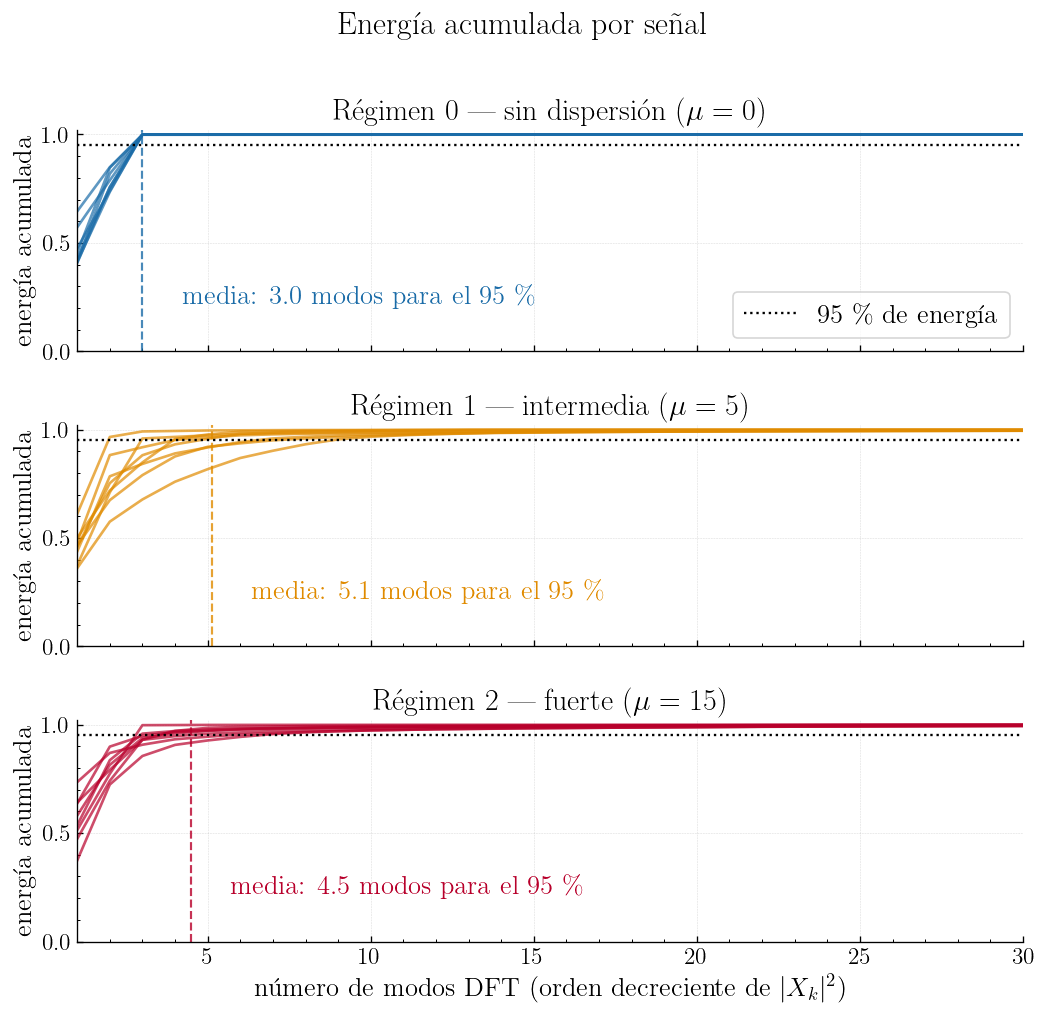

In [18]:
# Por cada régimen: curva de energía acumulada de sus 8 señales (una línea por señal), el
# umbral del 95 % y una vertical en el promedio de modos que hacen falta para alcanzarlo.
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True, sharey=True)
for ax, reg in zip(axes, (0, 1, 2)):
    modos_reg = []
    for i in np.where(regimenes == reg)[0]:
        n_modos, acumulada = modos_para_95(senales[i])
        ax.plot(np.arange(1, len(acumulada) + 1), acumulada, color=COLOR_REG[reg], lw=1.6, alpha=0.7)
        modos_reg.append(n_modos)
    media_modos = float(np.mean(modos_reg))

    ax.axhline(0.95, color="k", ls=":", lw=1.4)                                # umbral del 95 %
    ax.axvline(media_modos, color=COLOR_REG[reg], ls="--", lw=1.3, alpha=0.8)  # promedio de modos
    ax.annotate(fr"media: {media_modos:.1f} modos para el 95 \%",
                xy=(media_modos, 0.30), xytext=(media_modos + 1.2, 0.22), color=COLOR_REG[reg])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("energía acumulada")
    ax.set_title(NOMBRE_REG[reg])

axes[0].set_xlim(1, 30)
axes[-1].set_xlabel(r"número de modos DFT (orden decreciente de $|X_k|^2$)")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([0], [0], color="k", ls=":", lw=1.4, label=r"95 \% de energía")],
               loc="lower right")
fig.suptitle("Energía acumulada por señal", y=1.0)
fig.tight_layout()
plt.show()


## 4.1 Reconstrucción truncada con los $K=15$ modos más fuertes
Reconstruimos cada señal con sólo los 15 modos DFT más energéticos y medimos el error relativo.

**En esta celda** definimos `reconstruir_truncado` , una función que mantiene solo los K modos más fuertes y aplica la DFT inversa, y comparamos, por régimen, la señal original con su versión truncada, anotando el error relativo.

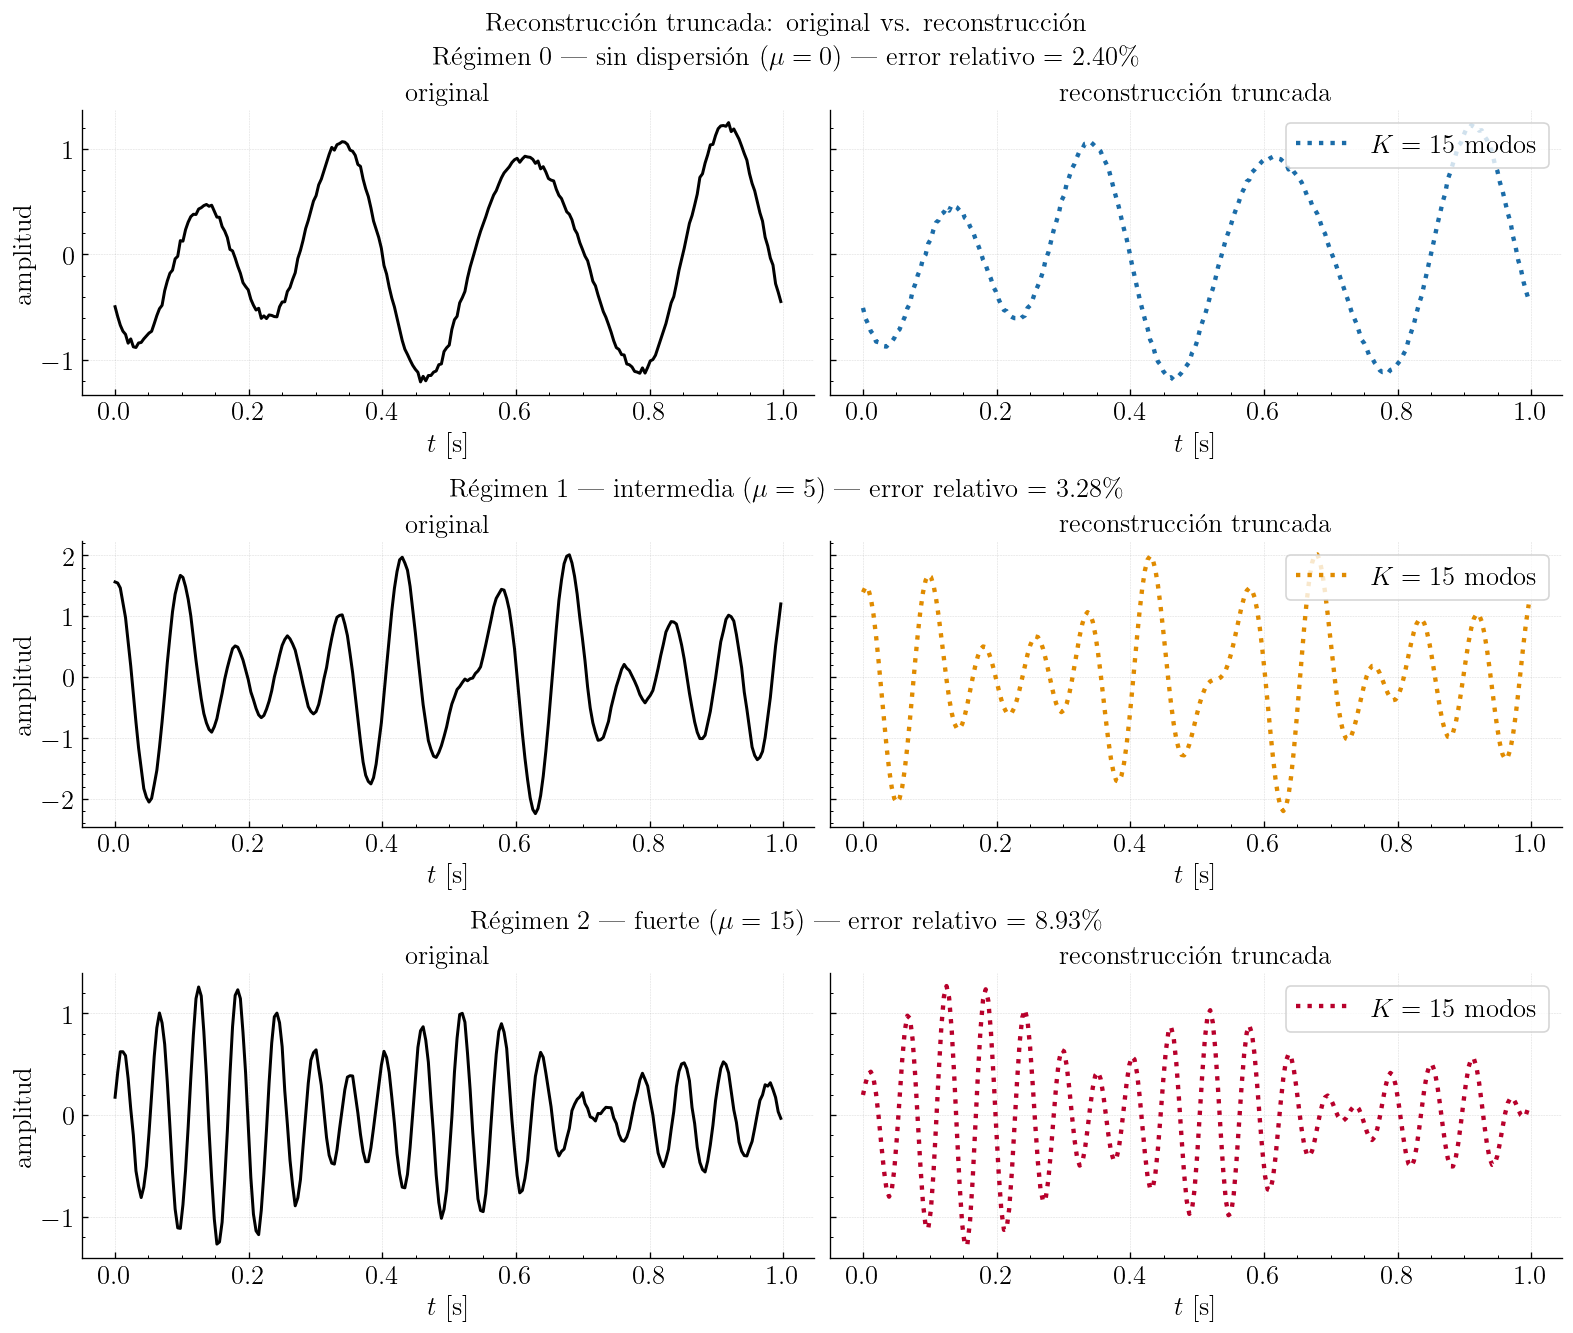

In [19]:
def reconstruir_truncado(senal, K_mantener=15):
    """Reconstruye la señal usando solo los 'K_mantener' modos DFT más energéticos."""
    espectro = np.fft.rfft(senal)
    energia = np.abs(espectro) ** 2
    energia[0] = 0.0                                       # ignoramos DC al elegir modos
    top_modos = np.argsort(energia)[::-1][:K_mantener]     # índices de los K modos más fuertes
    espectro_truncado = np.zeros_like(espectro)
    espectro_truncado[top_modos] = espectro[top_modos]
    return np.fft.irfft(espectro_truncado, n=senal.size), top_modos

# Todo el texto de esta figura al MISMO tamaño (16 pt)
TAM = 16
with plt.rc_context({"font.size": TAM, "axes.titlesize": TAM, "axes.labelsize": TAM,
                     "xtick.labelsize": TAM, "ytick.labelsize": TAM,
                     "legend.fontsize": TAM, "figure.titlesize": TAM}):
    fig = plt.figure(figsize=(13, 11), layout="constrained")
    subfigs = fig.subfigures(3, 1)
    for sf, reg in zip(subfigs, (0, 1, 2)):
        indice = np.where(regimenes == reg)[0][0]
        senal = senales[indice]
        recon_truncada, _ = reconstruir_truncado(senal, K_mantener=K)
        err_relativo = np.linalg.norm(senal - recon_truncada) / np.linalg.norm(senal)
        ax = sf.subplots(1, 2, sharey=True)
        ax[0].plot(tiempo, senal, "-", color="k", lw=1.8)
        ax[0].set_title("original")
        ax[0].set_ylabel("amplitud")
        ax[0].set_xlabel(r"$t$  [s]")
        ax[1].plot(tiempo, recon_truncada, ":", color=COLOR_REG[reg], lw=2.6, label=fr"$K={K}$ modos")
        ax[1].set_title("reconstrucción truncada")
        ax[1].set_xlabel(r"$t$  [s]")
        ax[1].legend(loc="upper right")
        sf.suptitle(fr"{NOMBRE_REG[reg]} — error relativo $=$ {err_relativo*100:.2f}\%")
    fig.suptitle("Reconstrucción truncada: original vs. reconstrucción")
    plt.show()


## 4.2 Error de reconstrucción vs. número de coeficientes conservados
Barremos el número de coeficientes DFT conservados $K$ y medimos el **error de reconstrucción relativo** $\lVert\hat x-x\rVert/\lVert x\rVert$ (media sobre las 8 señales de cada régimen). Cuantos más coeficientes, menor el error: la curva muestra a partir de cuántos la reconstrucción ya es buena, y confirma por qué **pocos** modos bastan.


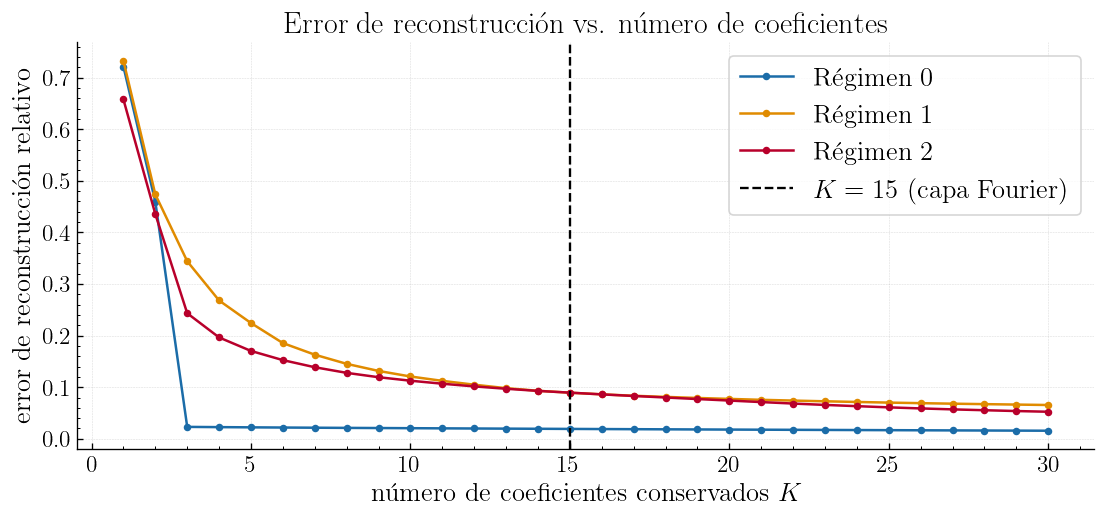

In [20]:
# Barremos el número de coeficientes DFT conservados y, para cada valor, medimos el error
# de reconstrucción relativo promediado sobre las 8 señales de cada régimen.
Ks = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for reg in (0, 1, 2):
    err_medio = []
    for K_keep in Ks:
        # error relativo de cada señal del régimen al conservar K_keep coeficientes
        errs = []
        for i in np.where(regimenes == reg)[0]:
            recon, _ = reconstruir_truncado(senales[i], K_mantener=int(K_keep))
            errs.append(np.linalg.norm(senales[i] - recon) / np.linalg.norm(senales[i]))
        err_medio.append(np.mean(errs))
    ax.plot(Ks, err_medio, marker="o", ms=3.5, color=COLOR_REG[reg], label=f"Régimen {reg}")

ax.axvline(K, color="k", ls="--", lw=1.4, label=fr"$K={K}$ (capa Fourier)")
ax.set_xlabel(r"número de coeficientes conservados  $K$")
ax.set_ylabel(r"error de reconstrucción relativo")
ax.set_title("Error de reconstrucción vs. número de coeficientes")
ax.legend()
fig.tight_layout()
plt.show()


# Parte V — Aprendizaje en el espacio de frecuencias - Experimento independiente

Hasta aquí la red se entrenó comparando su salida con la **señal original**. 
Ahora se propone un experimento que nace de la curiosidad de entender la Transformada de Fourier y su capacidad de traducir entre el dominio del tiempo y el dominio de frecuencias.

En este experimento independiente a lo pedido exploramos la pregunta: ¿Qué pasa si comparamos la salida de la red neuronal con el espectro de la DFT?

Para realizar este experimento se hacen las siguientes consideraciones:

- Inicializamos $W_1$ con la **matriz de Fourier**, tal y como se realizó en la Parte III.
- Actualizamos la función de pérdida para que sea una MSE que mide contra la **transformada de Fourier** $\Phi x$ de la señal original.
- Para evaluar, tomamos la salida $\hat y$ de la red y la llevamos de vuelta al tiempo con la **transformada inversa** $\hat x = \Phi^\top \hat y$, y la comparamos con la señal original $x$.

Esta construcción permite a la red aprender **dentro del espacio de frecuencias**, y sus valores de salida $\hat y$ son precisamente el espectro de la señal correspondiente.
Aquí buscamos ver si existe alguna diferencia entre entrenar dentro del dominio temporal o dentro del dominio de frecuencias.

Las consideraciones previas nos llevan a una arquitectura dada por:

$$\mathcal{L}_{\text{freq}}(W_1,W_2)=\frac1N\bigl\lVert\, \hat y - \Phi x\,\bigr\rVert^2,
\qquad \hat y = W_2\tanh(W_1 x),\qquad \hat x = \Phi^\top\hat y .$$

Donde $\Phi$ será una **matriz de Fourier real ortonormal** (256×256) que servirá de transformada. Sus filas son la versión *completa y normalizada* de las mismas $\cos/\sin$ que forman $W_1$. 

## 5.1 Construcción y verificación de la transformada $\Phi$

In [21]:
def matriz_fourier_ortonormal(N):
    """Base de Fourier real ortonormal de N filas: el término DC, los pares coseno/seno
    y el término de Nyquist. Al ser ortonormal, su transpuesta es su inversa."""
    n = np.arange(N)
    filas = [np.ones(N) / np.sqrt(N)]                    # DC (k=0)
    for k in range(1, N // 2):
        filas.append(np.sqrt(2 / N) * np.cos(2 * np.pi * k * n / N))
        filas.append(np.sqrt(2 / N) * np.sin(2 * np.pi * k * n / N))
    filas.append(np.cos(np.pi * n) / np.sqrt(N))         # Nyquist (k=N/2)
    return np.array(filas)

Phi   = matriz_fourier_ortonormal(n_muestras)
Phi_j = jnp.asarray(Phi)

# Comprobamos que Phi es ortonormal y que su transpuesta la invierte exactamente.
x0 = senales[0]
print("Phi shape:", Phi.shape)
print(f"ortonormal:      max|Phi Phi^T - I|   = {np.max(np.abs(Phi @ Phi.T - np.eye(n_muestras))):.2e}")
print(f"inversa exacta:  max|Phi^T Phi x - x| = {np.max(np.abs(Phi.T @ (Phi @ x0) - x0)):.2e}")


Phi shape: (256, 256)
ortonormal:      max|Phi Phi^T - I|   = 1.72e-14
inversa exacta:  max|Phi^T Phi x - x| = 1.56e-14


## 5.2 Entrenamiento en el espacio de frecuencias
Misma arquitectura e init Fourier que la Parte III, mismo $W_2$ compartido, mismo optimizador (SGD+momento, $\eta=0.05$, 3000 iter, 3 semillas). Lo único que cambia es el **objetivo** ($\Phi x$ en vez de $x$). Durante el entrenamiento medimos el **error de reconstrucción en el tiempo**, $\tfrac1N\lVert\Phi^\top\hat y - x\rVert^2$.

In [22]:
def loss_freq(params, X, Xf):
    """MSE en el espacio de frecuencias: compara la salida de la red con el espectro Phi·x."""
    return jnp.mean((forward(params, X) - Xf) ** 2)

@jit
def paso_freq(params, vel, X, Xf, lr=0.05, beta=0.9):
    """Un paso de SGD con momento, pero minimizando la pérdida en frecuencia."""
    val, grads = value_and_grad(loss_freq)(params, X, Xf)
    vel    = jax.tree_util.tree_map(lambda v, g: beta * v + g, vel, grads)
    params = jax.tree_util.tree_map(lambda p, v: p - lr * v, params, vel)
    return params, vel, val

@jit
def recon_mse(params, X):
    """Error en el TIEMPO del modelo entrenado en frecuencia: x_hat = Phi^T · y_hat."""
    return jnp.mean((forward(params, X) @ Phi_j - X) ** 2)

# Repetimos el experimento de la Parte III (init Fourier, mismo W2, 3 semillas), pero el
# objetivo ahora es el espectro Phi·x. Guardamos el error de reconstrucción en el tiempo
# para poder compararlo con el de la Parte III.
res_freq = {r: {"recon": np.zeros((N_SEEDS, N_ITER))} for r in (0, 1, 2)}
for s in range(N_SEEDS):
    key = random.PRNGKey(SEMILLA + s)
    _, key_w2 = random.split(key)              # el mismo W2 que usó el modelo Fourier
    for reg in (0, 1, 2):
        Xr = jnp.asarray(senales[regimenes == reg])
        Xf = Xr @ Phi_j.T                       # objetivo en frecuencia = Phi·x
        params = init_fourier(tiempo, K, key_w2)
        vel = jax.tree_util.tree_map(jnp.zeros_like, params)
        for i in range(N_ITER):
            params, vel, _ = paso_freq(params, vel, Xr, Xf)
            res_freq[reg]["recon"][s, i] = float(recon_mse(params, Xr))
        if s == N_SEEDS - 1:
            res_freq[reg]["params_last"] = params

print("Error de reconstrucción final (media sobre semillas):")
for reg in (0, 1, 2):
    l_freq = res_freq[reg]["recon"][:, -1].mean()
    l_time = resultados[reg]["fourier"]["loss"][:, -1].mean()
    print(f"  régimen {reg}:  entrenada en frecuencia = {l_freq:.2e}   entrenada en el tiempo = {l_time:.2e}")


Error de reconstrucción final (media sobre semillas):
  régimen 0:  entrenada en frecuencia = 9.73e-12   entrenada en el tiempo = 2.44e-11
  régimen 1:  entrenada en frecuencia = 4.35e-14   entrenada en el tiempo = 1.61e-13
  régimen 2:  entrenada en frecuencia = 3.03e-09   entrenada en el tiempo = 3.19e-09


## 5.3 Comprobación del aprendizaje del espectro
Aquí confirmaremos si en efecto la red neuronal entrenada en el espacio de frecuencias es capaz de reconstruir la señal en ambos dominios.
Izquierda: la reconstrucción $\hat x=\Phi^\top\hat y$ sobre la señal original. Derecha: el espectro aprendido $\hat y$ frente al espectro real $\Phi x$ (primeros coeficientes, donde vive la energía).

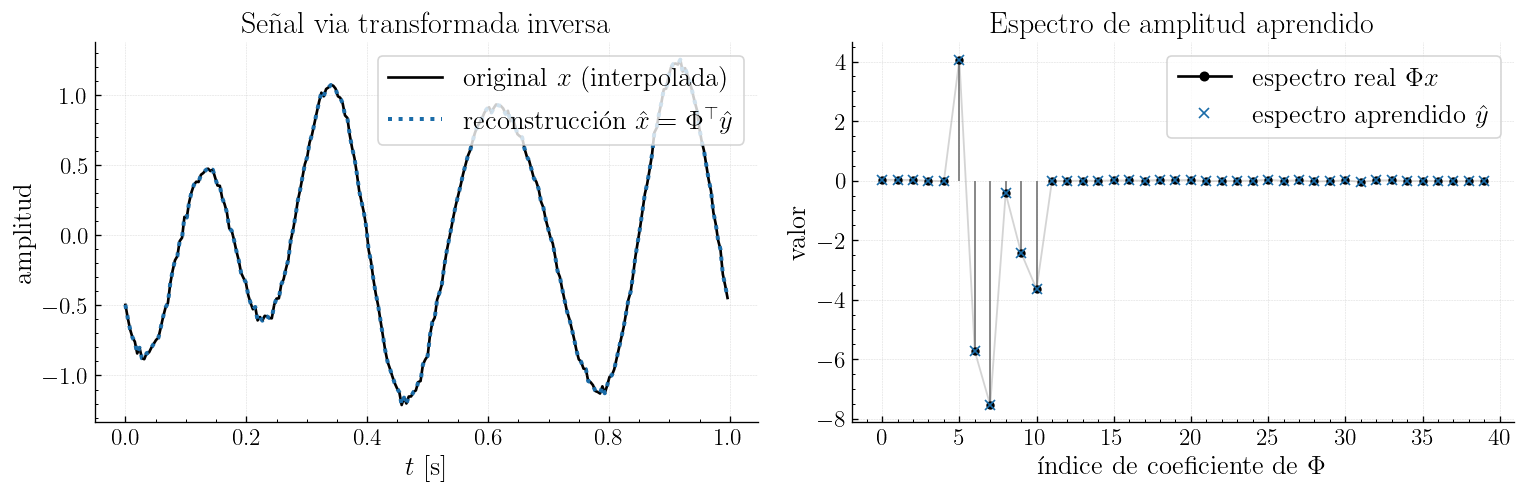

In [23]:
# Izquierda: la señal original y la reconstrucción vía transformada inversa.
# Derecha: el espectro que aprendió la red frente al espectro real de la señal.
reg = 0
p   = res_freq[reg]["params_last"]
x   = senales[np.where(regimenes == reg)[0][0]]
yhat   = np.asarray(forward(p, jnp.asarray(x[None, :])))[0]   # espectro que produce la red
xhat   = yhat @ Phi                                           # su reconstrucción en el tiempo
target = Phi @ x                                             # espectro real de la señal

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Panel izquierdo: original (negra) vs reconstrucción (punteada del color del régimen).
axes[0].plot(tiempo, x, "-", color="k", lw=1.6, zorder=1, label=r"original  $x$ (interpolada)")
axes[0].plot(tiempo, xhat, ":", color=COLOR_REG[reg], lw=2.4, zorder=3,
             label=r"reconstrucción  $\hat x=\Phi^\top\hat y$")
axes[0].set_xlabel(r"$t$  [s]")
axes[0].set_ylabel("amplitud")
axes[0].set_title("Señal via transformada inversa")
axes[0].legend(loc="upper right")

# Panel derecho: espectro real como stem discreto y espectro aprendido como cruces encima.
m = 40
coef = np.arange(m)
axes[1].plot(coef, target[:m], color="0.45", lw=1.1, alpha=0.30, zorder=1)   # silueta tenue de fondo
marcas, tallos, _ = axes[1].stem(coef, target[:m], basefmt=" ")
plt.setp(tallos, color="0.45", lw=1.0)
plt.setp(marcas, color="k", markersize=4)

axes[1].plot(coef, yhat[:m], marker="x", linestyle="none", markersize=5.5, color=COLOR_REG[reg])
axes[1].set_xlabel(r"índice de coeficiente de $\Phi$")
axes[1].set_ylabel("valor")
axes[1].set_title("Espectro de amplitud aprendido")

from matplotlib.lines import Line2D
h_esp = [Line2D([0], [0], color="k", lw=1.6, marker="o", ms=5, label=r"espectro real  $\Phi x$"),
         Line2D([0], [0], color=COLOR_REG[reg], lw=0, marker="x", ms=6, label=r"espectro aprendido  $\hat y$")]
axes[1].legend(handles=h_esp, loc="upper right")
fig.tight_layout()
plt.show()


## 5.4 Comparación de las reconstrucciones en frecuencia y en el tiempo.
Comparamos el **error de reconstrucción de la señal** de los dos modelos donde se inicializó la primera capa con Fourier, aquel donde se entrenó con la pérdida en frecuencia y el otro con la pérdida en el tiempo.

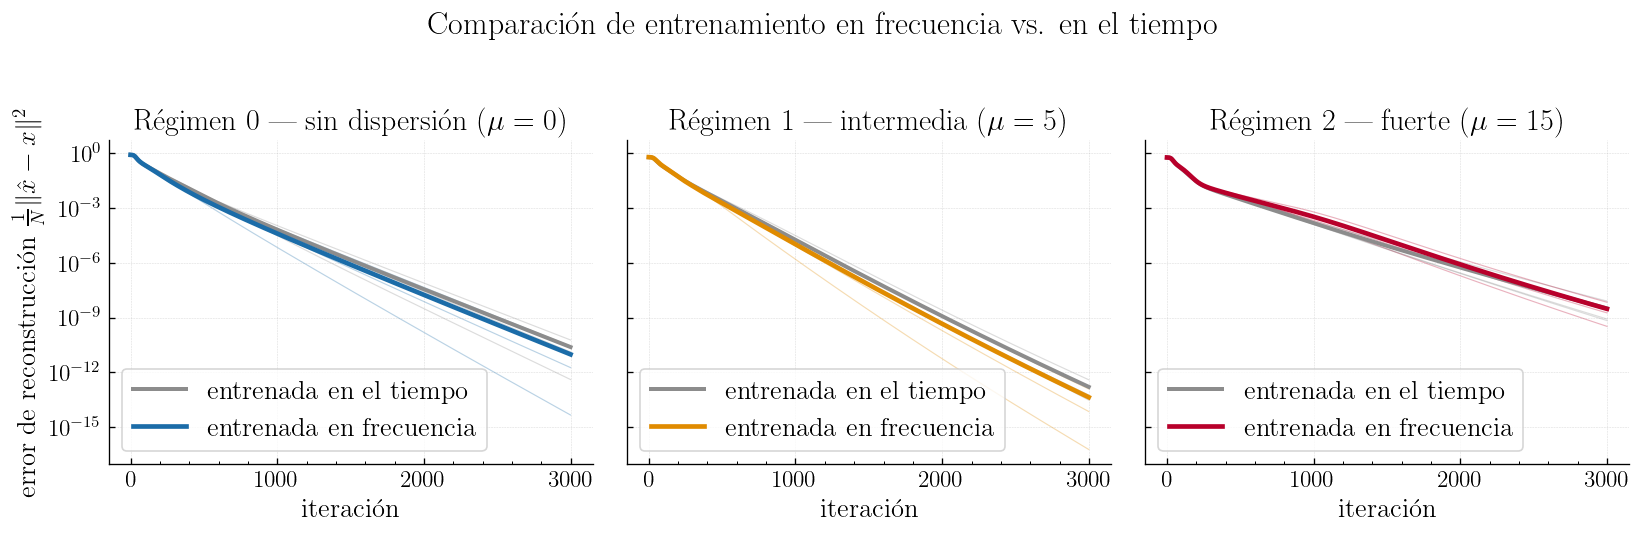

In [24]:
# Error de reconstrucción de dos modelos con init Fourier: uno entrenado en el tiempo
# (Parte III) y otro en frecuencia (Parte V). Coinciden, tal como predice Parseval.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
it = np.arange(N_ITER)
for ax, reg in zip(axes, (0, 1, 2)):
    recon_freq = res_freq[reg]["recon"]              # error del modelo entrenado en frecuencia
    recon_time = resultados[reg]["fourier"]["loss"]  # error del modelo entrenado en el tiempo
    for s in range(N_SEEDS):   # las semillas, tenues
        ax.semilogy(it, recon_time[s], color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.semilogy(it, recon_freq[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    ax.semilogy(it, recon_time.mean(0), color=COLOR_RANDOM, lw=2.4, label="entrenada en el tiempo")
    ax.semilogy(it, recon_freq.mean(0), color=COLOR_REG[reg], lw=2.8, label="entrenada en frecuencia")
    ax.set_title(NOMBRE_REG[reg])
    ax.set_xlabel("iteración")
    ax.legend()

axes[0].set_ylabel(r"error de reconstrucción $\frac{1}{N}\|\hat x-x\|^2$")
fig.suptitle("Comparación de entrenamiento en frecuencia vs. en el tiempo", y=1.02)
fig.tight_layout()
plt.show()


## 5.5 ¿Hubo diferencia?: Relación de Parseval

**Lo que dice Parseval.** Si $\Phi$ es ortonormal, es decir $\Phi^\top\Phi=I$, la transformada conserva la norma: para cualquier vector $v$ se cumple
$$\lVert\Phi v\rVert=\lVert v\rVert.$$
En palabras, la energía de una señal es la misma en el tiempo que en frecuencia, porque $\Phi$ solo cambia el sistema de coordenadas y no la longitud del vector.

**Por qué implica que los dos errores coinciden.** Queremos comparar el error medido en frecuencia, $\lVert\hat y-\Phi x\rVert^2$, con el error de reconstrucción en el tiempo, $\lVert\Phi^\top\hat y-x\rVert^2$. Como $\Phi^\top\Phi=I$, la señal cumple $x=\Phi^\top\Phi x$, y al sustituirla queda $\Phi^\top\hat y - x = \Phi^\top(\hat y-\Phi x)$. Aplicando entonces Parseval al vector $\hat y-\Phi x$, y usando que $\Phi^\top$ también es ortonormal, la norma no cambia:

$$\lVert\Phi^\top\hat y - x\rVert^2=\lVert\Phi^\top(\hat y-\Phi x)\rVert^2=\lVert\hat y-\Phi x\rVert^2=N\,\mathcal{L}_{\text{freq}}.$$

El error en el tiempo y el error en frecuencia son, entonces, la misma cantidad. Lo verificamos numéricamente en los pesos finales:


In [25]:
reg = 0

p   = res_freq[reg]["params_last"]
Xr  = jnp.asarray(senales[regimenes == reg])
Xf  = Xr @ Phi_j.T

L_freq  = float(jnp.mean((forward(p, Xr) - Xf) ** 2))          # error en frecuencia
L_recon = float(jnp.mean((forward(p, Xr) @ Phi_j - Xr) ** 2))  # error en el tiempo

print(f"L_freq (en frecuencia)      = {L_freq:.6e}")
print(f"L_recon (en el tiempo)      = {L_recon:.6e}")
print(f"|L_freq - L_recon|          = {abs(L_freq - L_recon):.2e}   -> idénticos (debido a Parseval)")

L_freq (en frecuencia)      = 4.616222e-15
L_recon (en el tiempo)      = 4.616222e-15
|L_freq - L_recon|          = 1.13e-23   -> idénticos (debido a Parseval)


## 5.6 Lectura del experimento
Entrenar la red contra el espectro $\Phi x$ y luego invertir reconstruye la señal igual de bien que entrenar directamente en el tiempo. La razón es Parseval: como $\Phi$ es ortonormal, el error en frecuencia y el error en el tiempo son la misma cantidad, de modo que Fourier no solo es un buen punto de partida sino un espacio de trabajo equivalente al del tiempo para esta tarea.


# Parte VI — Conclusiones

## Discusión: respuestas a las preguntas de la evaluación

### Capa Fourier
`np.fft.rfft` recibe una señal real de 256 muestras y devuelve 129 coeficientes complejos, cada uno con la amplitud y la fase de una frecuencia; puede aplicarse a una señal o a varias a la vez con `axis=1`. Reportamos la energía media del dataset porque fija la escala de la pérdida, ya que $\mathcal{L}(0)\approx\langle x^2\rangle$, y permite convertir el MSE en error relativo mediante $\sqrt{\mathcal{L}/\langle x^2\rangle}$, lo que da sentido al umbral de error relativo 0.1 de la Parte III.

### Entrenamiento y reconstrucción
El error se mide entre la salida de la red y la señal original, sobre las mismas señales con las que se entrenó y no sobre un conjunto de validación, así que mide ajuste y no generalización; es lo pertinente aquí porque el enunciado plantea reconstruir pocas señales por régimen y no pide partición. Entre las dos parametrizaciones no hay diferencia apreciable al final: ambas reconstruyen con errores relativos del mismo orden, y la ventaja de Fourier está en la velocidad, no en el error final.

### Comparación de inicializaciones
La pérdida no es el error relativo: la pérdida es el MSE y el error relativo es $\sqrt{\mathcal{L}/\langle x^2\rangle}$, de modo que pedir un error relativo menor que 0.1 equivale a pedir $\mathcal{L}<0.01\,\langle x^2\rangle$. Con ese criterio, en el régimen 0, el que destaca el enunciado, Fourier cruza el umbral algo antes y su pérdida se mantiene entre un 5 % y un 9 % por debajo de la aleatoria en la fase inicial, porque las señales de ese régimen viven en frecuencias bajas que la base cubre desde el arranque.

### Compresión
Con el umbral del 95 % de la energía, las señales del régimen 0 necesitan tres modos y las del resto entre tres y nueve, así que las quince frecuencias de la capa sobran en número. La limitación no es la cantidad de coeficientes sino su ubicación, como se ve en el régimen 2, cuyas frecuencias caen fuera de la banda que la capa cubre.

## Conclusión: ¿conviene inicializar en la base de Fourier?

La pregunta que guió el trabajo era si conviene arrancar la primera capa en la base de Fourier en lugar de una aleatoria. La respuesta es que sí, pero de forma condicional. La capa Fourier, en su punto de partida, calcula exactamente la transformada de Fourier de la señal, así que la red arranca ya mirando sus frecuencias, mientras que la aleatoria debe descubrirlas desde cero.

Esa ventaja se nota en la velocidad, no en el resultado final: como la primera capa también se entrena, ambas inicializaciones acaban reconstruyendo igual de bien y la diferencia está solo en la fase inicial. En el régimen 0, el que pide el enunciado, la pérdida de Fourier se mantiene entre un 5 % y un 9 % por debajo de la aleatoria de forma consistente. Lo que decide si esa ayuda aparece es dónde viven las frecuencias: la capa solo cubre las primeras quince y a las señales les bastan entre tres y nueve modos, así que sobran coeficientes. En los regímenes 0 y 1 las frecuencias caen dentro de la banda y Fourier ayuda; en el régimen 2 los picos suben a la banda de 15 a 19 Hz, fuera del alcance de la capa, y las dos inicializaciones se comportan igual.

En definitiva, inicializar en la base de Fourier acelera el entrenamiento siempre que las señales quepan en la banda de frecuencias que la base cubre. No es una receta universal sino una decisión informada por el problema: cuando se sabe que las señales son sumas de pocos cosenos a frecuencias bajas, empezar en la base correcta es una ventaja real; cuando no, la elección deja de importar.
